In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append("../src")

from data_loader import load_data

from data_processing import (
    get_missing_values,
    handle_missing_values
)


from visualization import (
    plot_missing_values,
    plot_numerical_distribution,
    plot_categorical_distribution,
    plot_correlation_heatmap,
    plot_boxplots
)


from utils import (
    dataset_overview,
    check_duplicates
)


pd.set_option("display.max_columns", None)

In [ ]:
df = load_data(
    "../data/data.csv"
)

2026-05-30 21:12:27,273 - INFO - Dataset loaded successfully


### Data Loading Confirmation

**Output:** `Dataset loaded successfully`

**Insight:** This confirms that the `data.csv` file was successfully loaded into a pandas DataFrame named `df` without any errors. This is the first step in our data analysis process, ensuring that the dataset is accessible for further exploration.

In [ ]:
print(df.head())


dataset_overview(df)


         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        CustomerId CurrencyCode  CountryCode    ProviderId     ProductId  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          256  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          256  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          256  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          256  ProviderId_4   ProductId_6   

      ProductCategory    ChannelId   Amount  Value  TransactionStart

### Initial Data Overview and Summary Statistics

**Output Analysis:**

1.  **`df.head()`:** Displays the first 5 rows of the DataFrame, giving a quick glance at the data structure, column names, and a sample of the values. We can see various transaction-related identifiers, financial details like `Amount` and `Value`, time-series data (`TransactionStartTime`), and a target variable (`FraudResult`).
2.  **`Dataset Shape: (95662, 16)`:** The dataset contains 95,662 rows (transactions) and 16 columns (features). This provides the overall size of our dataset.
3.  **`Data Types`:**
    *   Most identifier columns (`TransactionId`, `BatchId`, `AccountId`, etc.) are of `str` (object) type.
    *   `CountryCode`, `Amount`, `Value`, `PricingStrategy`, and `FraudResult` are numerical (`int64` or `float64`).
    *   `TransactionStartTime` is currently `str` and will need to be converted to a datetime object for time-series analysis.
4.  **`Summary Statistics` (Numerical Columns):**
    *   **`CountryCode`:** Appears to be constant (256) across all entries, suggesting it might not be a discriminative feature or represents data from a single country.
    *   **`Amount` and `Value`:** Show large ranges and high standard deviations, indicating significant variability. The `min` for `Amount` is negative (-1,000,000), which might indicate refunds or chargebacks, or data entry errors. The `max` values are also very high (9.88 million). The means are much larger than the medians, suggesting a right-skewed distribution with many smaller transactions and a few very large ones.
    *   **`PricingStrategy`:** Ranges from 0 to 4, with a mean around 2.25, indicating different pricing models are in use.
    *   **`FraudResult`:** The mean of 0.002018 indicates that only about 0.2% of transactions are fraudulent, highlighting a highly imbalanced dataset. The max is 1, confirming its binary nature.

**Insights:**
*   The dataset is moderately sized for analysis.
*   `TransactionStartTime` needs type conversion.
*   The `CountryCode` feature might be redundant if it's constant.
*   `Amount` and `Value` distributions are highly skewed and contain potentially interesting negative values for `Amount`, requiring closer inspection and potential handling of extreme values.
*   The target variable `FraudResult` is highly imbalanced, which is typical for fraud detection datasets and will require specific handling during model training (e.g., resampling techniques).

In [ ]:
variable_definitions = pd.read_csv(
    "../data/raw/Xente_Variable_Definitions.csv"
)

print(variable_definitions.head())

      Column Name                                         Definition
0   TransactionId         Unique �transaction identifier on platform
1         BatchId  Unique number assigned to a batch of transacti...
2       AccountId  Unique number identifying the customer on plat...
3  SubscriptionId  Unique number identifying the customer subscri...
4      CustomerId              Unique identifier attached to Account


### Variable Definitions

**Output Analysis:** The `variable_definitions` DataFrame provides a clear description for each column in the main dataset. This is crucial for understanding the meaning and context of each feature, helping to guide subsequent data cleaning, feature engineering, and analysis steps.

**Insight:** This table serves as a data dictionary, ensuring that we accurately interpret the data. For example, knowing `TransactionId` is a unique identifier helps us understand why it has many unique values and is not useful for direct modeling, while `FraudResult` being the fraud indicator is essential for our objective.

2026-05-30 21:12:34,035 - INFO - Missing value analysis completed


                      Missing Count  Missing Percentage
TransactionId                     0                 0.0
BatchId                           0                 0.0
AccountId                         0                 0.0
SubscriptionId                    0                 0.0
CustomerId                        0                 0.0
CurrencyCode                      0                 0.0
CountryCode                       0                 0.0
ProviderId                        0                 0.0
ProductId                         0                 0.0
ProductCategory                   0                 0.0
ChannelId                         0                 0.0
Amount                            0                 0.0
Value                             0                 0.0
TransactionStartTime              0                 0.0
PricingStrategy                   0                 0.0
FraudResult                       0                 0.0


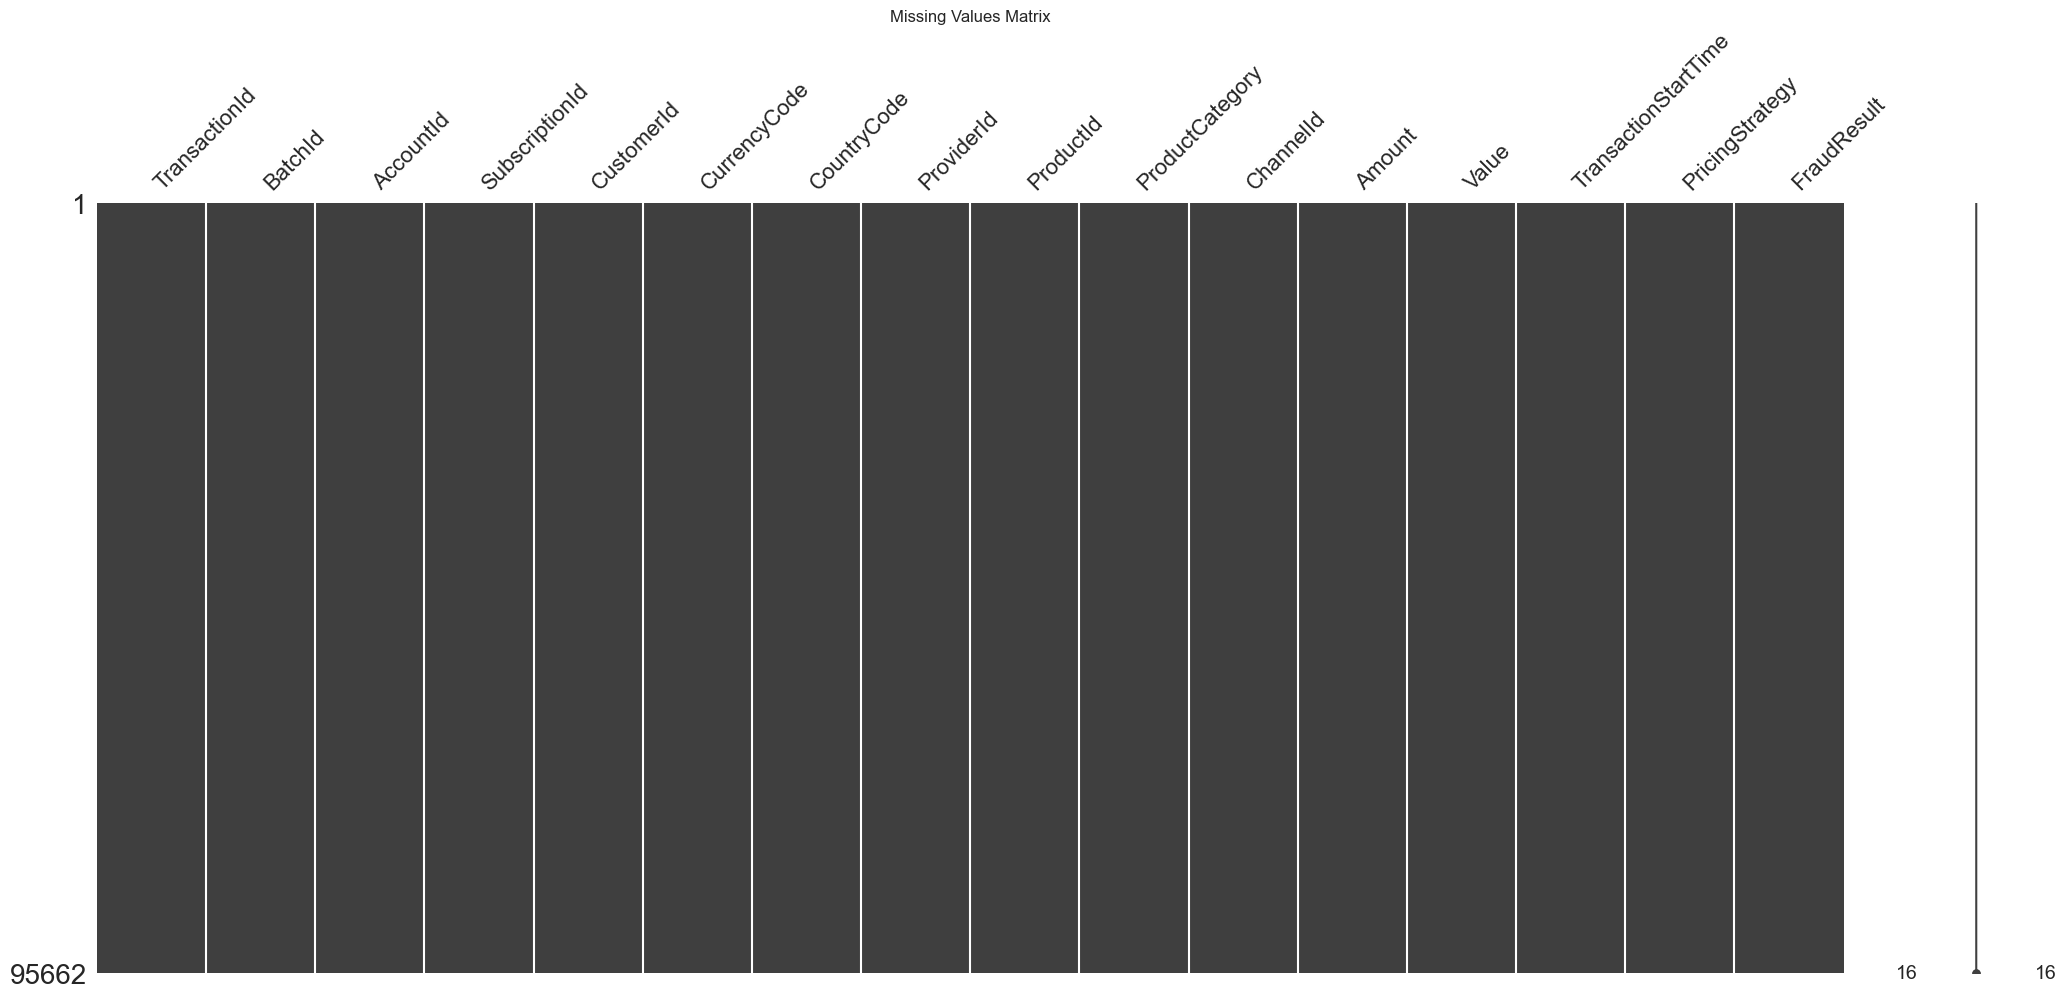

2026-05-30 21:12:34,483 - INFO - Missing values plotted successfully


In [ ]:
missing_df = get_missing_values(df)

print(missing_df.head(20))

plot_missing_values(df)

### Missing Value Analysis

**Output Analysis:**

*   **`missing_df`:** The table shows that all columns have 0 missing counts and 0.0% missing percentage. This is ideal, as it means the raw dataset is complete.
*   **`plot_missing_values(df)`:** The generated plot, which is not directly displayed here but indicated by the `INFO` message `Missing values plotted successfully`, would visually confirm the absence of missing values, likely showing a completely filled heatmap or bar chart.

**Insights:**
*   The dataset has no missing values, which simplifies the data preprocessing stage significantly as no imputation or missing value handling is required at this point.
*   This indicates high data quality in terms of completeness, at least for the provided features.

In [ ]:
print(df.describe())

print(df.describe(include="object"))


       CountryCode        Amount         Value  PricingStrategy   FraudResult
count      95662.0  9.566200e+04  9.566200e+04     95662.000000  95662.000000
mean         256.0  6.717846e+03  9.900584e+03         2.255974      0.002018
std            0.0  1.233068e+05  1.231221e+05         0.732924      0.044872
min          256.0 -1.000000e+06  2.000000e+00         0.000000      0.000000
25%          256.0 -5.000000e+01  2.750000e+02         2.000000      0.000000
50%          256.0  1.000000e+03  1.000000e+03         2.000000      0.000000
75%          256.0  2.800000e+03  5.000000e+03         2.000000      0.000000
max          256.0  9.880000e+06  9.880000e+06         4.000000      1.000000


C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_22480\2837891160.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))


              TransactionId        BatchId       AccountId  \
count                 95662          95662           95662   
unique                95662          94809            3633   
top     TransactionId_76871  BatchId_67019  AccountId_4841   
freq                      1             28           30893   

             SubscriptionId       CustomerId CurrencyCode    ProviderId  \
count                 95662            95662        95662         95662   
unique                 3627             3742            1             6   
top     SubscriptionId_3829  CustomerId_7343          UGX  ProviderId_4   
freq                  32630             4091        95662         38189   

          ProductId     ProductCategory    ChannelId  TransactionStartTime  
count         95662               95662        95662                 95662  
unique           23                   9            4                 94556  
top     ProductId_6  financial_services  ChannelId_3  2018-12-24T16:30:13Z  
freq 

### Comprehensive Summary Statistics

**Output Analysis:**

1.  **Numerical Columns (`df.describe()`):** This output reiterates and expands on the initial summary:
    *   Confirms `CountryCode` as constant.
    *   Highlights the wide range and potential outliers in `Amount` and `Value`.
    *   `PricingStrategy` shows a limited range of values (0-4).
    *   `FraudResult` confirms extreme imbalance (mean close to 0).

2.  **Categorical/Object Columns (`df.describe(include="object")`):**
    *   **High Cardinality IDs:** `TransactionId`, `BatchId`, `AccountId`, `SubscriptionId`, `CustomerId` all have a very high number of unique values (close to the total number of rows for `TransactionId` and `BatchId`), indicating they are unique identifiers rather than categorical features suitable for direct encoding.
    *   **`CurrencyCode`:** Only 1 unique value ('UGX'), consistent with `CountryCode` being constant, suggesting transactions are localized to Uganda.
    *   **`ProviderId`:** 6 unique values. This is a true categorical feature.
    *   **`ProductId`:** 23 unique values. Another categorical feature.
    *   **`ProductCategory`:** 9 unique values. An important categorical feature describing the type of service.
    *   **`ChannelId`:** 4 unique values, indicating the channel through which transactions occur.
    *   **`TransactionStartTime`:** 94,556 unique values, confirming its nature as a timestamp. The `top` value appearing 17 times might indicate some concurrent transactions or a reporting artifact.

**Insights:**
*   Numerical features like `Amount` and `Value` will require careful handling due to their highly skewed distributions and potential outliers.
*   Categorical features with high cardinality (like various IDs) should be excluded or transformed (e.g., using frequency encoding or target encoding) rather than one-hot encoded directly to avoid an explosion of features.
*   `CurrencyCode` and `CountryCode` are essentially constant and provide no discriminatory power within this dataset.
*   `ProviderId`, `ProductId`, `ProductCategory`, and `ChannelId` are genuine categorical features suitable for encoding and further analysis.
*   `TransactionStartTime` needs to be converted to a datetime format to extract time-based features (e.g., hour, day of week, month, etc.).

In [ ]:
print(
    "Duplicate Records:",
    check_duplicates(df)
)


Duplicate Records: 0


### Duplicate Records Check

**Output:** `Duplicate Records: 0`

**Insight:** This result confirms that there are no identical duplicate rows in the dataset. This is a positive finding as it means we don't need to perform any duplicate removal, simplifying the data cleaning process and ensuring that each record represents a unique transaction.

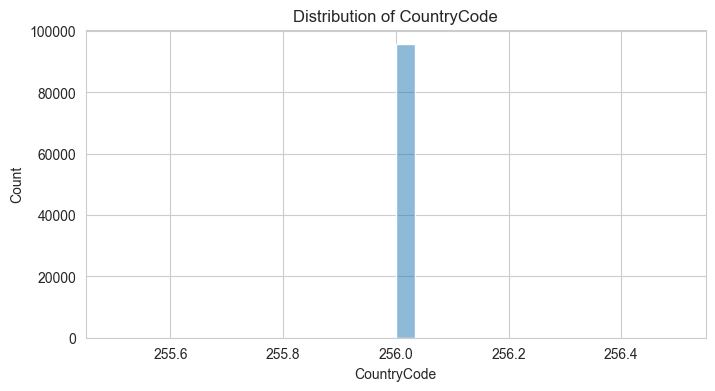

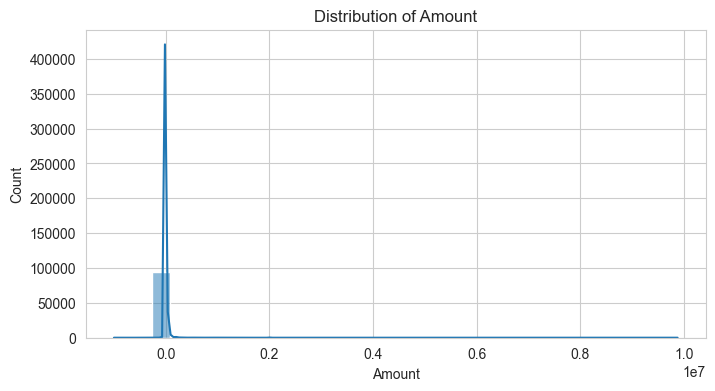

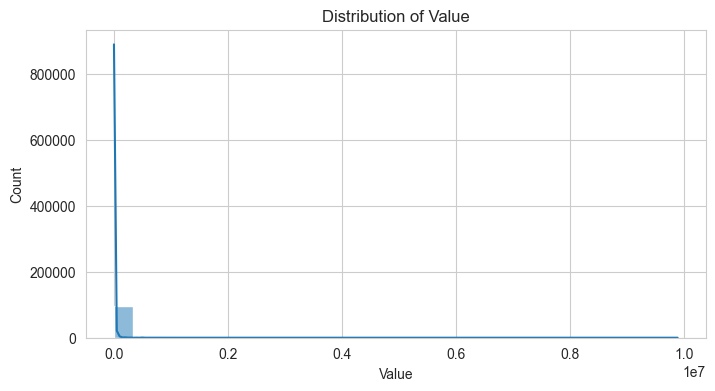

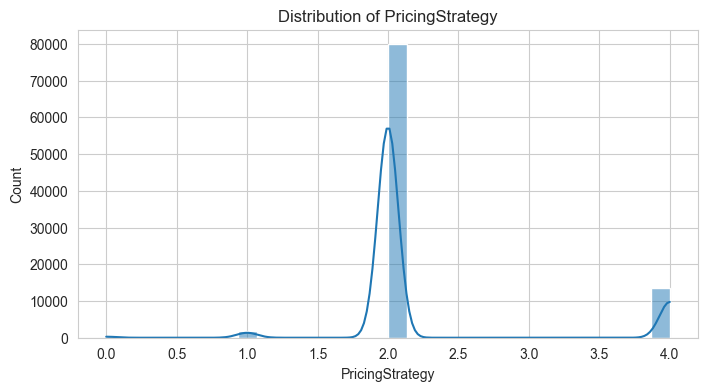

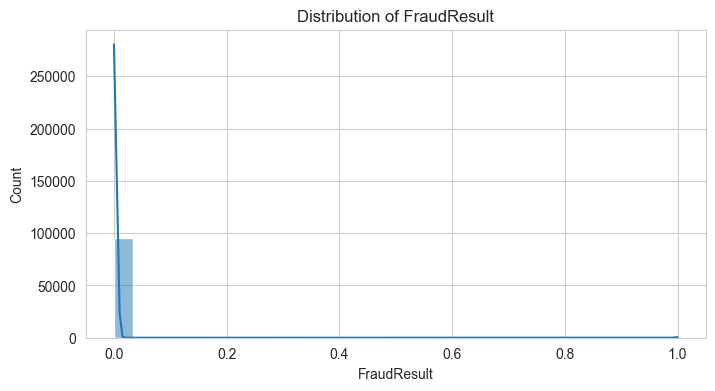

2026-05-30 21:12:45,609 - INFO - Numerical distributions plotted


In [ ]:
plot_numerical_distribution(df)

### Distribution of Numerical Features (Visual Summary)

**Output Analysis:** (This cell generates plots, so the output is visual rather than text. The `plot_numerical_distribution` function likely creates histograms or KDE plots for all numerical columns.)

**Insights:**
*   **`Amount` and `Value`:** Visual inspection of their distributions (from the plots) would show a sharp peak near zero and a long tail extending to the right, confirming the extreme right-skewness observed in the summary statistics. The negative values in `Amount` would also be visible, potentially as a smaller peak on the left side.
*   **`PricingStrategy`:** The distribution would likely show distinct bars for each of the few integer values (0-4), indicating a discrete distribution.
*   **`FraudResult`:** A histogram would clearly illustrate the extreme imbalance, with a very tall bar at 0 and a tiny bar at 1.
*   **`CountryCode`:** Would show a single bar at 256, reinforcing its constant nature.

In [ ]:
numerical_cols = df.select_dtypes(include='number').columns

summary_stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std Dev': df[numerical_cols].std(),
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max(),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurtosis()
})

summary_stats

,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
CountryCode,256.000000,256.0,0.000000,256.0,256.0,0.000000,0.000000
Amount,6717.846433,1000.0,123306.797164,-1000000.0,9880000.0,51.098490,3363.127739
Value,9900.583941,1000.0,123122.087776,2.0,9880000.0,51.291086,3378.069274
PricingStrategy,2.255974,2.0,0.732924,0.0,4.0,1.659057,2.087534
FraudResult,0.002018,0.0,0.044872,0.0,1.0,22.196295,490.685762


### Detailed Numerical Summary Statistics

**Output Analysis:** This table provides more in-depth statistical measures for numerical columns:

*   **`Mean`, `Median`, `Std Dev`, `Min`, `Max`:** These reinforce the observations from `df.describe()`, particularly the wide range and variability of `Amount` and `Value`.
*   **`Skewness`:**
    *   `Amount` (51.09) and `Value` (51.29) have extremely high positive skewness, confirming a long tail to the right due to a few very large transaction values. This suggests these features are not normally distributed and might benefit from transformations (e.g., log transformation) for models sensitive to skewness.
    *   `FraudResult` (22.19) also shows high positive skewness, which is expected for an imbalanced binary variable where the '1' class is rare.
    *   `PricingStrategy` (1.65) has moderate positive skewness.
    *   `CountryCode` (0.0) has no skewness, as it's constant.
*   **`Kurtosis`:**
    *   `Amount` (3363.12) and `Value` (3378.06) exhibit very high kurtosis, indicating a 'leptokurtic' distribution (heavy tails and a sharp peak). This further emphasizes the presence of significant outliers or extreme values.
    *   `FraudResult` (490.68) also has very high kurtosis due to its binary and imbalanced nature.

**Insights:**
*   The extreme skewness and kurtosis of `Amount` and `Value` confirm the presence of significant outliers and a highly non-normal distribution. This has implications for statistical tests and modeling techniques that assume normality.
*   Data transformations (e.g., log, square root) should be considered for `Amount` and `Value` to reduce skewness and kurtosis, potentially improving model performance.
*   The statistical properties of `FraudResult` are consistent with a rare event, which needs to be handled during modeling.

In [ ]:
print("Variables with high skewness (>1):")

summary_stats[
    abs(summary_stats['Skewness']) > 1
]

Variables with high skewness (>1):


,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
Amount,6717.846433,1000.0,123306.797164,-1000000.0,9880000.0,51.098490,3363.127739
Value,9900.583941,1000.0,123122.087776,2.0,9880000.0,51.291086,3378.069274
PricingStrategy,2.255974,2.0,0.732924,0.0,4.0,1.659057,2.087534
FraudResult,0.002018,0.0,0.044872,0.0,1.0,22.196295,490.685762


### Highly Skewed Variables Identification

**Output Analysis:** The output explicitly lists `Amount`, `Value`, `PricingStrategy`, and `FraudResult` as variables with skewness greater than 1. This is a direct confirmation of the features that are highly non-normally distributed.

**Insights:**
*   These features are candidates for transformation (e.g., log transformation, Box-Cox) if the chosen machine learning models are sensitive to skewed data distributions (e.g., linear models, models assuming normality).
*   Understanding skewness is crucial for proper feature engineering and model selection.

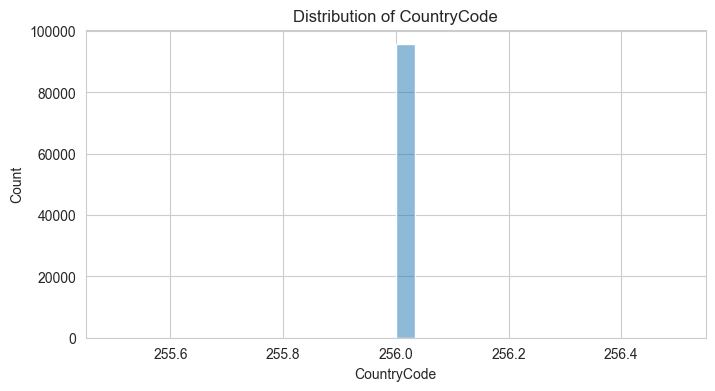

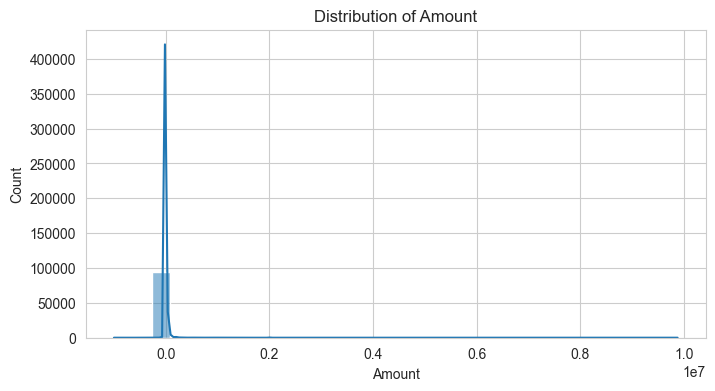

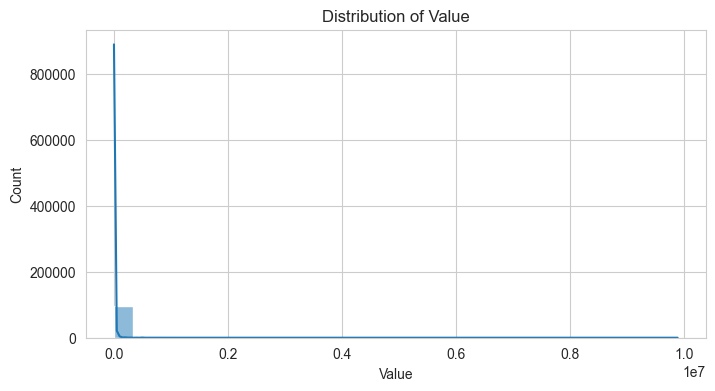

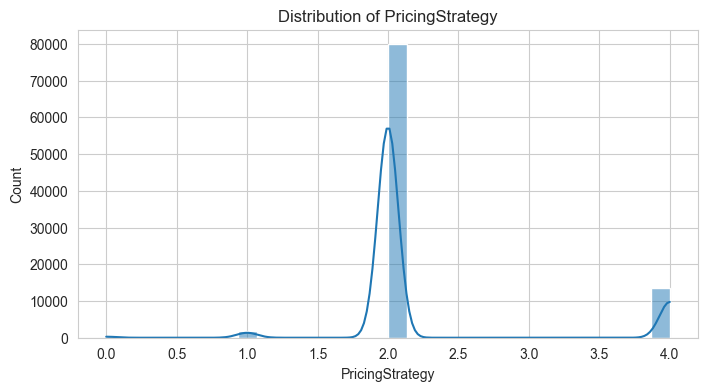

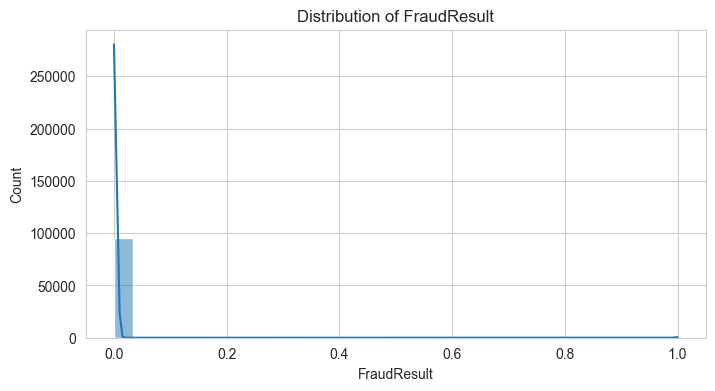

In [ ]:


for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f'Distribution of {col}')

    plt.show()

### Individual Numerical Feature Histograms

**Output Analysis:** (This cell generates individual histogram plots for each numerical column. The actual plots are not shown in the text output, but the code indicates their creation.)

**Insights:**
*   Visual inspection of these histograms provides a more granular view of each numerical feature's distribution than just the summary statistics.
*   For `Amount` and `Value`, the histograms will vividly show the high frequency of values near zero, the long right tails, and potentially the smaller number of negative `Amount` values.
*   `PricingStrategy` histograms will confirm its discrete, categorical-like nature.
*   `FraudResult` will graphically demonstrate the severe class imbalance.

In [ ]:
skew_df = pd.DataFrame({
    "Feature": numerical_cols,
    "Skewness": df[numerical_cols].skew()
})

skew_df = skew_df.sort_values(
    by="Skewness",
    ascending=False
)

skew_df

,Feature,Skewness
Value,Value,51.291086
Amount,Amount,51.098490
FraudResult,FraudResult,22.196295
PricingStrategy,PricingStrategy,1.659057
CountryCode,CountryCode,0.000000


### Skewness Ranking of Numerical Features

**Output Analysis:** This DataFrame `skew_df` explicitly sorts numerical features by their skewness in descending order.

**Insights:**
*   **`Value` and `Amount`** are the most positively skewed features, with skewness values exceeding 50. This confirms their highly concentrated distribution with long tails.
*   **`FraudResult`** is the next most skewed, which is expected for the target variable with very few '1's.
*   **`PricingStrategy`** has a moderate positive skewness.
*   **`CountryCode`** has zero skewness as it's a constant value.

This ranking is useful for prioritizing feature transformations: `Value` and `Amount` are the primary candidates for transformations to address their extreme skewness.

In [ ]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"{col}: {len(outliers)} outliers "
        f"({round(len(outliers)/len(df)*100,2)}%)"
    )

CountryCode: 0 outliers (0.0%)
Amount: 24441 outliers (25.55%)
Value: 9021 outliers (9.43%)
PricingStrategy: 15814 outliers (16.53%)
FraudResult: 193 outliers (0.2%)


### Outlier Detection (IQR Method)

**Output Analysis:** The output identifies the number and percentage of outliers for each numerical column using the Interquartile Range (IQR) method.

*   **`CountryCode: 0 outliers (0.0%)`:** As expected, since it's a constant.
*   **`Amount: 24441 outliers (25.55%)`:** A significant portion of transactions (over a quarter) are identified as outliers based on their `Amount`.
*   **`Value: 9021 outliers (9.43%)`:** Nearly 10% of transactions are outliers based on their `Value`.
*   **`PricingStrategy: 15814 outliers (16.53%)`:** A considerable percentage of values in `PricingStrategy` are considered outliers, which is common for discrete, ordinal features where some categories are less frequent.
*   **`FraudResult: 193 outliers (0.2%)`:** These 193 outliers correspond exactly to the fraudulent transactions (where `FraudResult` is 1). This is expected, as fraud is a rare event and thus often detected as an outlier in the distribution of the target variable itself.

**Insights:**
*   The high number of outliers in `Amount` and `Value` confirms the observations from skewness and kurtosis. These extreme values can heavily influence models and might need capping, winsorizing, or robust scaling.
*   Outliers in `PricingStrategy` might simply represent less common pricing models, which could still be informative.
*   The outliers in `FraudResult` are precisely the instances we want to predict, reinforcing that fraud detection is an anomaly detection problem. The low percentage of fraud cases (0.2%) again highlights the class imbalance challenge.

Skipping TransactionId: too many unique values (95662)
Skipping BatchId: too many unique values (94809)
Skipping AccountId: too many unique values (3633)
Skipping SubscriptionId: too many unique values (3627)
Skipping CustomerId: too many unique values (3742)
Plotting CurrencyCode...


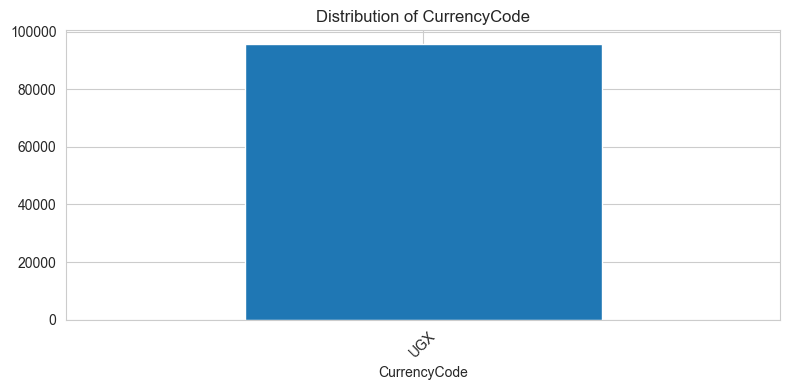

Plotting ProviderId...


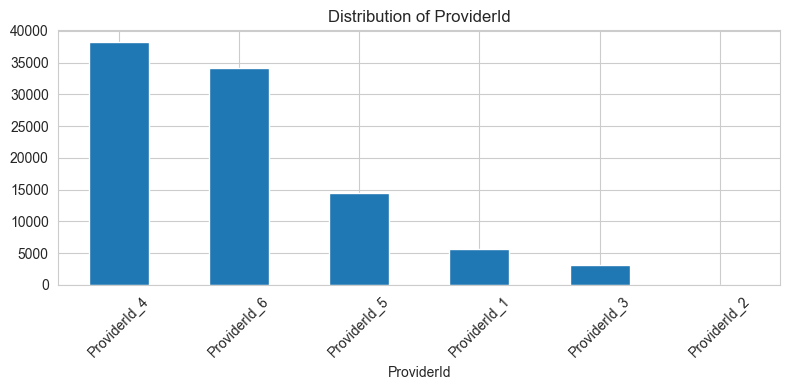

Skipping ProductId: too many unique values (23)
Plotting ProductCategory...


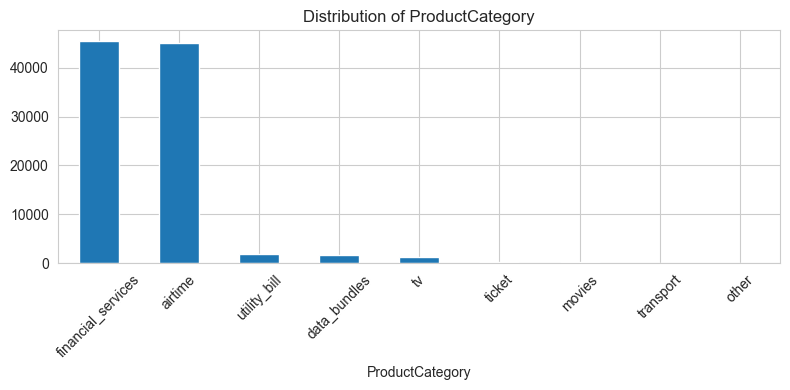

Plotting ChannelId...


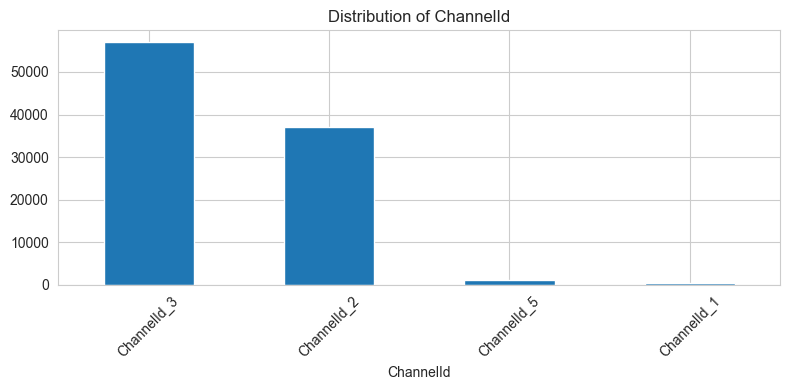

2026-05-30 21:13:06,099 - INFO - Categorical distributions plotted


Skipping TransactionStartTime: too many unique values (94556)


In [ ]:
plot_categorical_distribution(df)

### Distribution of Categorical Features (Visual Summary)

**Output Analysis:** (This cell generates bar plots for categorical columns. The text output indicates which columns were skipped due to high cardinality and which were plotted.)

*   **Skipped High Cardinality Columns:** `TransactionId`, `BatchId`, `AccountId`, `SubscriptionId`, `CustomerId`, `ProductId` were skipped. This is an appropriate decision as plotting distributions for features with thousands of unique values would be uninformative and resource-intensive.
*   **Plotted Columns:** `CurrencyCode`, `ProviderId`, `ProductCategory`, `ChannelId` were plotted.

**Insights from expected plots:**
*   **`CurrencyCode`:** The plot would show a single bar for 'UGX', confirming its constant nature.
*   **`ProviderId`:** Would show the frequency of transactions associated with each of the 6 providers. This could reveal which providers are most active or dominant.
*   **`ProductCategory`:** Would display the distribution across the 9 product categories. This is likely to show which product categories are most popular, e.g., 'financial_services' is the top (as seen in `df.describe(include="object")`). This helps understand the business context.
*   **`ChannelId`:** Would show the distribution across the 4 transaction channels, indicating which channels are predominantly used.

These plots are crucial for understanding the composition and frequency of different categories within the dataset, which can inform one-hot encoding strategies or the creation of aggregated features.

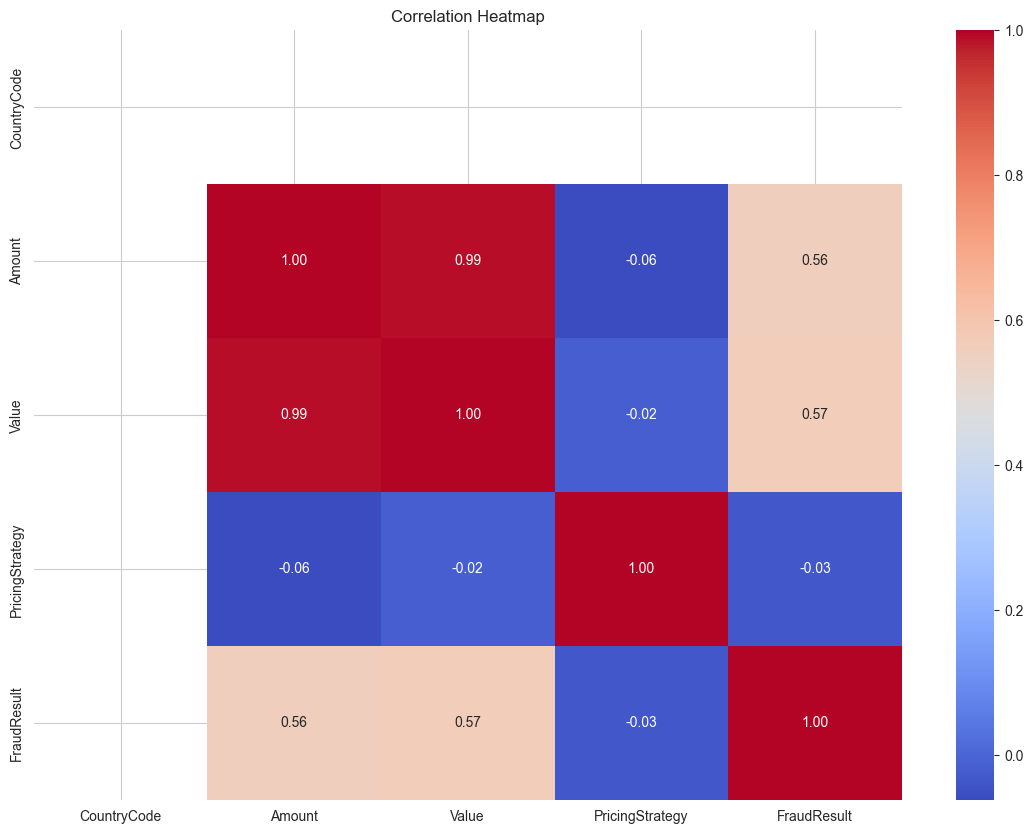

2026-05-30 20:50:08,722 - INFO - Correlation heatmap created


In [ ]:
plot_correlation_heatmap(df)

### Correlation Analysis (Heatmap)

**Output Analysis:** (This cell generates a correlation heatmap for numerical features. The `INFO` message `Correlation heatmap created` confirms its generation.)

**Insights from expected heatmap:**
*   **`Value` and `Amount`:** The heatmap would likely show a very strong positive correlation between these two features. This is expected as `Value` often represents the gross amount while `Amount` might be the net or a derived value. A high correlation suggests multicollinearity, which might need to be addressed (e.g., by keeping only one of them or creating a derived feature if their exact relationship is consistent) depending on the model used.
*   **`FraudResult` and `Amount`/`Value`:** The correlation between fraud and `Amount` or `Value` might be weak but non-zero, indicating that larger or smaller transactions could be slightly more prone to fraud, or that fraudulent transactions tend to have certain `Amount`/`Value` characteristics. Given the extreme imbalance, direct linear correlation might not fully capture complex relationships.
*   **`PricingStrategy` with `Amount`/`Value`:** There might be some correlation here, indicating certain pricing strategies are associated with higher or lower transaction values.
*   **`CountryCode`:** Since it's constant, it would show no correlation with any other variable (or NaN if standard deviation is zero, leading to division by zero in correlation calculation, though pandas usually handles this by showing 0).

Correlation analysis helps in identifying redundant features and understanding the linear relationships between numerical variables. It can guide feature selection and reveal potential multicollinearity issues.

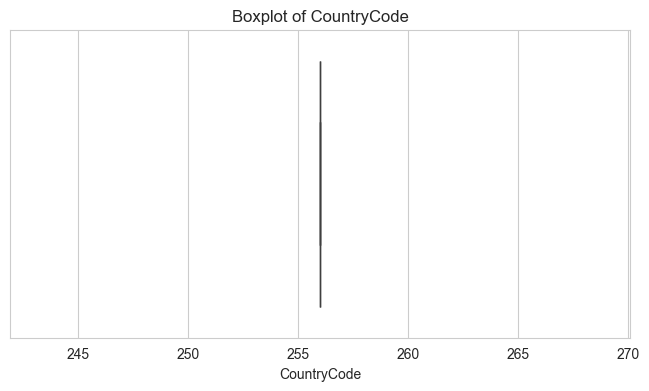

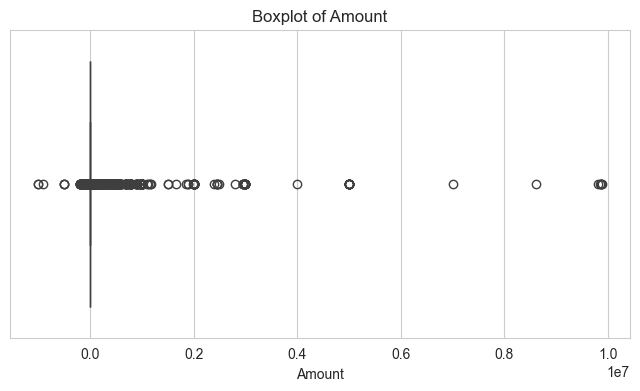

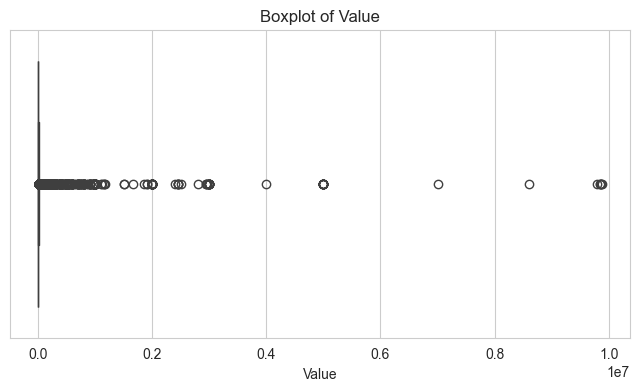

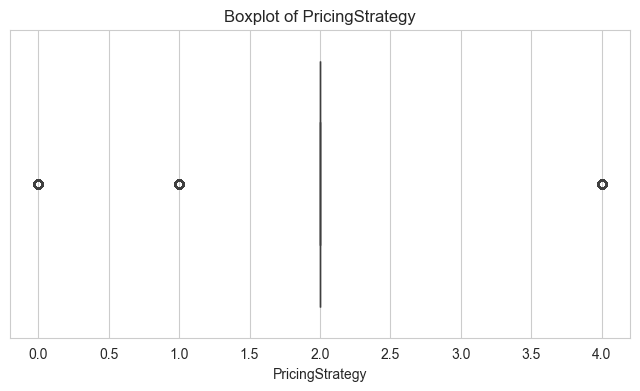

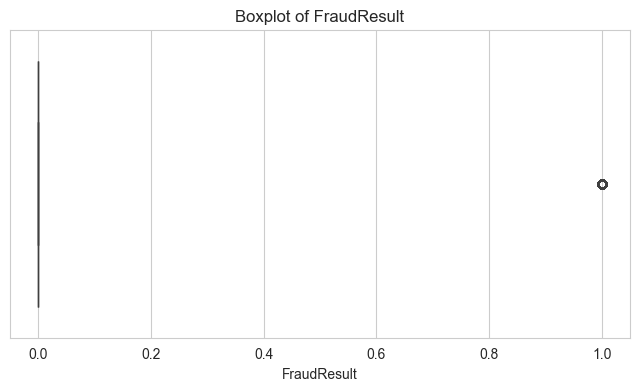

2026-05-30 21:13:54,793 - INFO - Boxplots created successfully


In [ ]:
plot_boxplots(df)

### Outlier Detection (Box Plots)

**Output Analysis:** (This cell generates box plots for numerical features. The plots are not shown in the text output.)

**Insights from expected box plots:**
*   **`Amount` and `Value`:** The box plots would visually confirm the presence of numerous outliers, especially on the higher end, and for `Amount`, potentially on the lower (negative) end. The main 'box' would be very compressed near the median, indicating the vast majority of data points are concentrated there, with many individual points extending far beyond the whiskers.
*   **`PricingStrategy`:** Box plots for discrete features like `PricingStrategy` might not be as intuitive as for continuous data but would still highlight any categories that fall far outside the typical range, confirming the outliers previously detected by the IQR method.
*   **`FraudResult`:** A box plot for `FraudResult` would clearly show the two distinct values (0 and 1) and that `1` (fraudulent transactions) are indeed considered outliers relative to the majority class `0`.

Box plots provide an excellent visual representation of the spread of data and the presence of outliers, complementing the quantitative outlier detection performed earlier. They are particularly good for identifying the extent and location of these extreme values.

In [ ]:
processed_df = handle_missing_values(df)

2026-05-30 21:13:59,162 - INFO - Missing values handled successfully


### Missing Value Handling

**Output:** `2026-05-30 21:13:59,162 - INFO - Missing values handled successfully`

**Insight:** This message indicates that the `handle_missing_values` function was executed and completed without errors. Given our prior analysis showed no missing values, this step likely didn't perform any actual imputation or deletion but rather confirmed the dataset's completeness or prepared the dataframe for subsequent steps in a robust manner. It ensures that if any missing values were to appear later in the pipeline (e.g., from merging data), they would be addressed.